In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "ev_charging_stations_india_cleaned.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "deepeshkansotia/ev-charging-stations-in-india-openchargemap",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

/tmp/ipykernel_17/1735077050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


## Understanding the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
df.shape

(1000, 10)

In [4]:
df.columns

Index(['station_id', 'station_name', 'city', 'state', 'country', 'latitude',
       'longitude', 'charging_points', 'status', 'operator'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   station_id       1000 non-null   int64  
 1   station_name     1000 non-null   object 
 2   city             1000 non-null   object 
 3   state            1000 non-null   object 
 4   country          1000 non-null   object 
 5   latitude         1000 non-null   float64
 6   longitude        1000 non-null   float64
 7   charging_points  1000 non-null   int64  
 8   status           1000 non-null   object 
 9   operator         1000 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 78.3+ KB


In [6]:
df.describe()

,station_id,latitude,longitude,charging_points
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,411186.89600,15.015117,79.487028,2.364000
std,80212.30397,5.538109,4.091311,18.963415
min,313438.00000,8.194503,72.908046,1.000000
25%,313754.75000,10.148326,76.283157,1.000000
50%,474539.50000,11.669307,76.825038,1.000000
75%,479190.25000,20.193904,83.891772,2.000000
max,479727.00000,32.214505,91.851200,600.000000


In [7]:
df.head(10)

,station_id,station_name,city,state,country,latitude,longitude,charging_points,status,operator
0,479727,Nikol EV Charging station,Pune,Unknown,India,18.717182,74.182921,1,Operational,Unknown
1,479445,Blaze Fast Charger For 2 Ev Wheeler,Lb Nagar,Telangana,India,17.340476,78.545395,1,Operational,Bolt.Earth (IN)
2,479438,Tata Power Charging Station,Unknown,Odisha,India,22.286961,86.790983,1,Operational,Unknown
3,479437,Hindustan Petroleum Corporation Limited Chargi...,Unknown,Odisha,India,22.449744,86.594944,2,Operational,Unknown
4,479436,Hindustan Petroleum Corporation Limited,Unknown,Odisha,India,22.449858,86.595041,1,Operational,Unknown
5,479435,Jio-bp,Unknown,Odisha,India,22.140250,85.712650,1,Operational,Unknown
6,479434,Jio-bp,Unknown,Odisha,India,22.001540,85.327980,1,Operational,Unknown
7,479433,Ather Grid Charging Station,Unknown,Odisha,India,22.243666,84.827354,3,Operational,Unknown
8,479432,Ather Grid Charging Station,Unknown,Odisha,India,22.236660,84.770150,1,Operational,Unknown
9,479431,Ather Grid Charging Station,Unknown,Odisha,India,22.226705,84.864116,1,Operational,Unknown


In [8]:
df.tail(10)

,station_id,station_name,city,state,country,latitude,longitude,charging_points,status,operator
990,313447,Grand Mall,Edappalli,Kerala,India,10.024160,76.308712,3,Operational,Zeon Charging
991,313446,Gokul Oottupura Restaurant,Edappalli,Kerala,India,10.011145,76.312497,1,Operational,Zeon Charging
992,313445,Brunton Boatyard,Cochin,Kerala,India,9.968305,76.245709,1,Operational,Zeon Charging
993,313444,Casino Hotel,Kochi,Kerala,India,9.961431,76.269491,1,Operational,Zeon Charging
994,313443,Hotel Ganga Grand,Moovattupuzha,Kerala,India,9.981771,76.578304,2,Operational,Zeon Charging
995,313442,Eden Wood Resorts,Munnar,Kerala,India,10.025676,77.053771,1,Operational,Zeon Charging
996,313441,Club Mahindra Aleppey Resort,Arookutty,Kerala,India,9.859751,76.335824,2,Operational,Zeon Charging
997,313440,CGH Marari Beach,Mararikulam,Kerala,India,9.596034,76.302770,1,Operational,Zeon Charging
998,313439,Cassia Restaurant,Alappuzha,Kerala,India,9.518714,76.327485,2,Operational,Zeon Charging
999,313438,Hotel Aida,Kottayam,Kerala,India,9.582880,76.521686,1,Operational,Zeon Charging


## Data Cleaning

In [9]:
df['state'] = df['state'].str.title()

In [10]:
state_corrections = {
    "Mh": "Maharashtra",
    "Rj": "Rajasthan",
    "Gj": "Gujarat",
    "Mp": "Madhya Pradesh",
    "Tamilnadu": "Tamil Nadu",
    "New Dehi": "New Delhi",
    "Uttarakhnad": "Uttarakhand",
    "Keral": "Kerala",
    "Keraka": "Kerala",
    "Lerala": "Kerala"
}

df['state'] = df['state'].replace(state_corrections)

In [11]:
df[(df['state'] == 'Unknown') & (df['city'] != 'Unknown')]

,station_id,station_name,city,state,country,latitude,longitude,charging_points,status,operator
0,479727,Nikol EV Charging station,Pune,Unknown,India,18.717182,74.182921,1,Operational,Unknown
461,474587,Flash Charge EVCS | Thirivangoor,Thirivangoor,Unknown,India,11.382130,75.736612,1,Operational,ChargeMod (IN)
511,474468,AR Square EVCS | Kavalayoor,Kavalayur,Unknown,India,8.713974,76.779719,3,Operational,ChargeMod (IN)
540,471855,K2 Highway Treat & Resort,Guna,Unknown,India,24.684685,77.337371,2,Operational,Chargezone (India)
581,459990,Jio-BP Pulse,Yellagallahalli,Unknown,India,13.606273,77.787275,2,Operational,JIO BP Pulse (India)
914,313555,Muzhangodayil EVCS - ChargeMOD,Harippad,Unknown,India,9.251674,76.487233,2,Temporarily Unavailable,ChargeMod (IN)


In [12]:
city_state_map = {
    "Pune": "Maharashtra",
    "Thirivangoor": "Kerala",
    "Kavalayur": "Kerala",
    "Guna": "Madhya Pradesh",
    "Yellagallahalli": "Karnataka",
    "Harippad": "Kerala"
}
df.loc[df['state'] == 'Unknown', 'state'] = df['city'].map(city_state_map).fillna(df['state'])

## Checking for missing values and duplicates

In [13]:
df.isnull().sum()

station_id         0
station_name       0
city               0
state              0
country            0
latitude           0
longitude          0
charging_points    0
status             0
operator           0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

## Visualizations

### 1. Distribution of Charging Stations by State

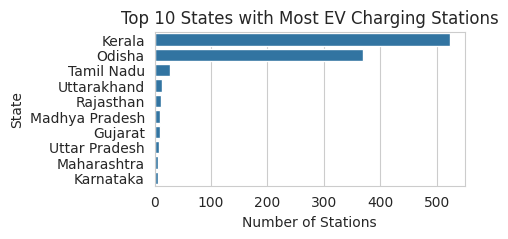

In [15]:
state_counts = df['state'].value_counts().head(10)
plt.figure(figsize=(4,2))
sns.barplot(x=state_counts.values, y=state_counts.index)
plt.title("Top 10 States with Most EV Charging Stations")
plt.xlabel("Number of Stations")
plt.ylabel("State")
plt.show()

### 2. Top Charging Operators

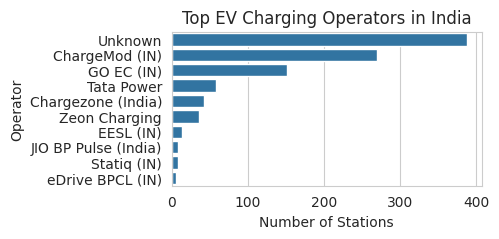

In [16]:
operator_counts = df['operator'].value_counts().head(10)
plt.figure(figsize=(4,2))
sns.barplot(x=operator_counts.values, y=operator_counts.index)
plt.title("Top EV Charging Operators in India")
plt.xlabel("Number of Stations")
plt.ylabel("Operator")
plt.show()

### 3. City-wise Charging Infrastructure

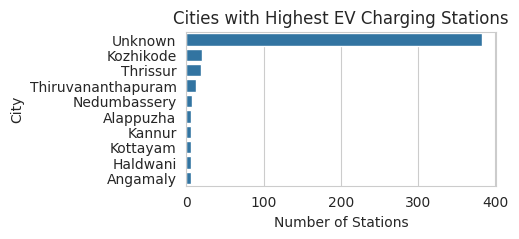

In [17]:
city_counts = df['city'].value_counts().head(10)
plt.figure(figsize=(4,2))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title("Cities with Highest EV Charging Stations")
plt.xlabel("Number of Stations")
plt.ylabel("City")
plt.show()

### 4. Charging Capacity Distribution

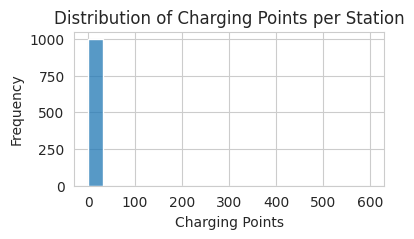

In [18]:
plt.figure(figsize=(4,2))
sns.histplot(df['charging_points'], bins=20)
plt.title("Distribution of Charging Points per Station")
plt.xlabel("Charging Points")
plt.ylabel("Frequency")
plt.show()

### 5. Operator Market Share

In [19]:
operator_share = df['operator'].value_counts(normalize=True).head(10) * 100
operator_share

operator
Unknown                 38.8
ChargeMod (IN)          27.0
GO EC (IN)              15.2
Tata Power               5.8
Chargezone (India)       4.2
Zeon Charging            3.6
EESL (IN)                1.4
JIO BP Pulse (India)     0.8
Statiq (IN)              0.8
eDrive BPCL (IN)         0.5
Name: proportion, dtype: float64

### 6. Geographic Visualization

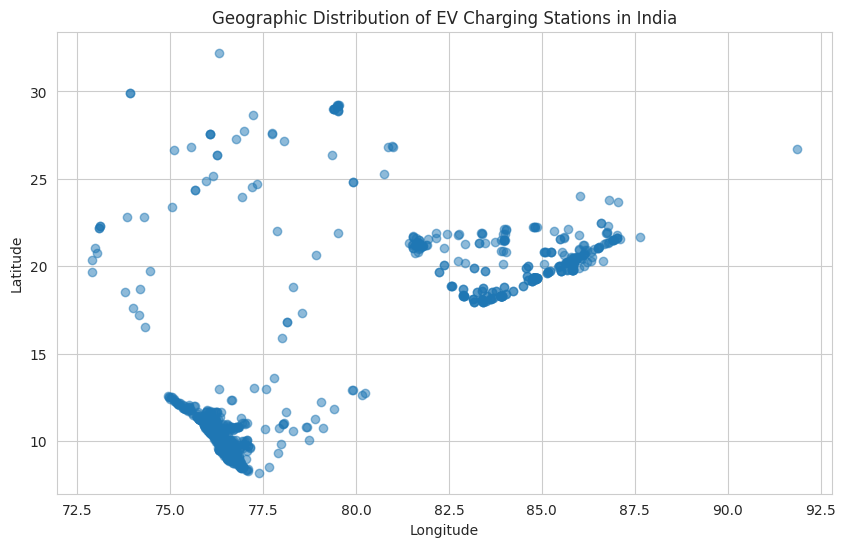

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df['longitude'], df['latitude'], alpha=0.5)
plt.title("Geographic Distribution of EV Charging Stations in India")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()